# Trabalho de `Teoria e Aplicação de Grafos`
##### Integrantes: `Arthur Vilaça Serodio`(Matrícula: 251039335) e `Gustavo Pires Dos Santos`(Matrícula: 251004349)
O objetivo do trabalho é analisar uma rede social real usando conceitos e métricas de grafos, com foco em identificar usuários mais influentes, importantes ou estratégicos para a disseminação de informações.
##### DataBase utilizada: https://snap.stanford.edu/data/egonetsFacebook.html 

## Importação dos Dados para o projeto

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

Facebook_graph = nx.read_edgelist("../DataBase/facebook_combined.txt",nodetype=int)
# Testando se a importação aconteceu corretamente
print(f"Número de nós no grafo: {Facebook_graph.number_of_nodes()}") #4039
print(f"Número de arestas no grafo: {Facebook_graph.number_of_edges()}") #88234

Número de nós no grafo: 4039
Número de arestas no grafo: 88234


# Sorteando 404 nós
Será utilizada a biblioteca `random` para sortear aleatoriamente 404 vértices do grafo. 
Assim, estamos formando um `subgrafo induzido` do grafo "Facebook_graph", visto que esse subgrafo é obtido pela escolha de alguns vértices do grafo original e mantemos todas as arestas existentes entre os vértices escolhidos.

In [2]:
import random
list_sorteados = random.sample(list(Facebook_graph.nodes()),404)
#Verificando se foi pego 404 nós
print(len(list_sorteados)) #404
#Convetendo de lista para grafo
Amostra_graph = Facebook_graph.subgraph(list_sorteados).copy()
#Verificando a amostra
print(f"Nós da amostra: {Amostra_graph.number_of_nodes()}") #404
print(f"Arestas da amostra: {Amostra_graph.number_of_edges()}") #Varia de acordo com a amostra

404
Nós da amostra: 404
Arestas da amostra: 716


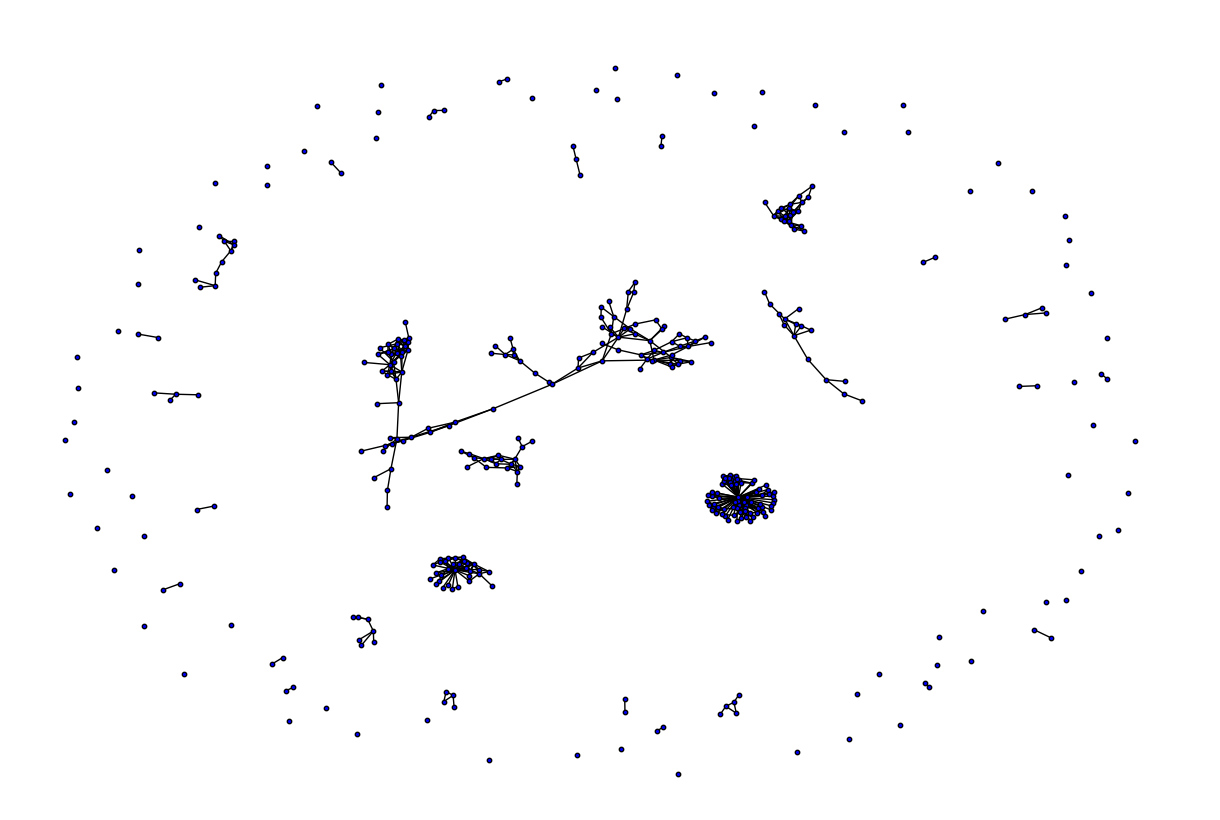

In [3]:
plt.figure(figsize=(12,8))
nx.draw(Amostra_graph, node_color='blue', node_size=10, edge_color='black', edgecolors='black', verticalalignment='center', horizontalalignment='center')
plt.show()

# Calculando cada medida de centralidade
* Grau: indica o grau do nó, quantas arestas se conecta a ele. Nas redes sociais, indica `popularidade/n° de seguidores`
* Intermediação: Quanto o usuário aparece nos caminhos entre outros usuários. Nas redes sociais, se vc segue uma pessoa, talvez vc queira seguir outra pessoa que esta pessoa segue.
* Proximidade: Quão perto o usuário está dos demais nós. Nas redes sociais, usuário que consegue alcançar rapidamente grande parte da rede -> `disseminação de informações`
* Autovetor: Ela não considera apenas quantas pessoas você conhece, Quem são as pessoas que você conhece?, Um nó é importante quando está conectado a outros nós importantes. Nas redes sociais, essa medida pode ser interpretada como `prestígio/influência estrutural`

In [6]:
#Centralidade de Intermediação
intermediacao = nx.betweenness_centrality(Amostra_graph)
#Centralidade de Proximidade
proximidade = nx.closeness_centrality(Amostra_graph)
#Centralidade de grau 
grau = nx.degree_centrality(Amostra_graph)
#Centralidade de autovetor 
autovetor = nx.eigenvector_centrality(Amostra_graph)

#Teste para ver as medidas de centralidade 
print("grau: ",grau)
print("intermediacao: ", intermediacao)
print("autovetor: ", autovetor)
print("proximidade: ", proximidade)

grau:  {2049: 0.01488833746898263, 2051: 0.004962779156327543, 4: 0.0024813895781637717, 2063: 0.03225806451612903, 2065: 0.007444168734491315, 19: 0.009925558312655087, 23: 0.004962779156327543, 2072: 0.02729528535980149, 29: 0.004962779156327543, 33: 0.0, 43: 0.0, 46: 0.0024813895781637717, 47: 0.0, 50: 0.004962779156327543, 51: 0.0024813895781637717, 2102: 0.024813895781637715, 58: 0.0024813895781637717, 2107: 0.017369727047146403, 65: 0.004962779156327543, 78: 0.0024813895781637717, 82: 0.009925558312655087, 2131: 0.04466501240694789, 2135: 0.009925558312655087, 102: 0.0, 2154: 0.034739454094292806, 109: 0.007444168734491315, 2158: 0.009925558312655087, 2160: 0.007444168734491315, 113: 0.004962779156327543, 2162: 0.007444168734491315, 2166: 0.007444168734491315, 2186: 0.007444168734491315, 140: 0.004962779156327543, 2188: 0.034739454094292806, 173: 0.004962779156327543, 2223: 0.019851116625310174, 177: 0.0024813895781637717, 2232: 0.024813895781637715, 2237: 0.02977667493796526, 22

# Aplicando o Algoritmo de Louvain 
* O Algoritmo de Louvain é um metodo utilizado para a detecção de grupos de nós que apresentam conexões entre si.
* O Algoritmo será utilizado para encontrar as comunidades a qual os usuários pertencem.
* Foi utilizada a biblioteca `python-louvain` para aplicar este algoritmo e calcular as referidas comunidades da rede. 

In [ ]:
import community as community_louvain 
particao = community_louvain.best_partition(Amostra_graph)
nx.set_node_attributes(Amostra_graph,particao,'comunidade')
num_comunidades = len(set(particao.values()))

#Teste para ver a quantidade de comunidades 
print("Numero de comunidades: ",num_comunidades)

Numero de comunidades:  107
